# Machine Learning 2 — Assignment #2: Reducción de Dimensionalidad y Clustering con DBSCAN (PCA, Kernel PCA, t-SNE y UMAP)

## Introducción

En este taller se exploran técnicas de **reducción de dimensionalidad** y su impacto sobre tareas de **clustering**. En particular, se aplicarán **PCA**, **Kernel PCA**, **t-SNE** y **UMAP** para proyectar datos de alta dimensión a un espacio de menor dimensión (2D), con el fin de evaluar si estas transformaciones mejoran la **separabilidad visual y estructural** de los grupos.

Posteriormente, se ejecutará el algoritmo **DBSCAN** sobre cada embedding generado para analizar cómo cambia el comportamiento del clustering según la técnica utilizada. Se comparará el **número de clusters detectados**, la **presencia de ruido (outliers)** y la estabilidad de los agrupamientos, discutiendo cuál método preserva mejor la estructura del conjunto de datos y si el espacio reducido ofrece una representación útil para segmentación y toma de decisiones.


In [26]:
import pandas                   as pd
import numpy                    as np
import matplotlib.pyplot        as plt
import seaborn as sns
from sklearn.preprocessing      import StandardScaler
from sklearn.preprocessing      import StandardScaler
from sklearn.decomposition      import PCA
from sklearn.decomposition      import KernelPCA
from sklearn.manifold           import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

## Reading, Cleaning and Analyzing the Data

In [2]:
df_fifa = pd.read_csv("../Data/df_FIFA_cleaned_processed.csv")                      # 1) Cargar datasets
df_air_raw = pd.read_csv("../Data/df_EastWestAirlines_processed.csv")

In [3]:
df_fifa_num = df_fifa.select_dtypes(include=[np.number]).copy()
df_air_clean = df_air_raw.drop(columns=["ID#", "Award?"], errors="ignore")  # Airlines (remover columnas no útiles si existen, luego filtrar numéricas)
df_air_num = df_air_clean.select_dtypes(include=[np.number]).copy()
print("FIFA num shape:", df_fifa_num.shape)
print("Airlines num shape:", df_air_num.shape)

FIFA num shape: (18852, 10)
Airlines num shape: (3999, 10)


In [4]:
df_fifa_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18852 entries, 0 to 18851
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Finishing        18852 non-null  float64
 1   Short Passing    18852 non-null  float64
 2   Standing Tackle  18852 non-null  float64
 3   Sprint Speed     18852 non-null  float64
 4   Strength         18852 non-null  float64
 5   Dribbling        18852 non-null  float64
 6   Crossing         18852 non-null  float64
 7   Interceptions    18852 non-null  float64
 8   Vision           18852 non-null  float64
 9   GK Reflexes      18852 non-null  float64
dtypes: float64(10)
memory usage: 1.4 MB


In [5]:
df_air_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Balance            3999 non-null   float64
 1   Qual_miles         3999 non-null   float64
 2   cc1_miles          3999 non-null   float64
 3   cc2_miles          3999 non-null   float64
 4   cc3_miles          3999 non-null   float64
 5   Bonus_miles        3999 non-null   float64
 6   Bonus_trans        3999 non-null   float64
 7   Flight_miles_12mo  3999 non-null   float64
 8   Flight_trans_12    3999 non-null   float64
 9   Days_since_enroll  3999 non-null   float64
dtypes: float64(10)
memory usage: 312.6 KB


## PCA

In [6]:
def select_optimal_pca(data, threshold=0.95):
    # 1. Standardize (PCA is sensitive to variance scales!)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # 2. Fit PCA on all possible components
    pca = PCA().fit(scaled_data)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    
    # 3. Find the first index where cumulative variance exceeds threshold
    # We add 1 because indices are 0-based
    n_components = np.argmax(cum_var >= threshold) + 1
    
    print(f"✅ To capture {threshold*100}% variance, you need {n_components} components.")
    
    # 4. Plotting the 'Discovery'
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='-', color='gray', alpha=0.3)
    
    # Highlight the chosen point
    plt.plot(n_components, cum_var[n_components-1], 'ro', markersize=10, label=f'Optimal: {n_components} comps')
    plt.axhline(y=threshold, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=n_components, color='r', linestyle='--', alpha=0.5)
    
    plt.title(f'PCA: {n_components} Components for {threshold*100}% Variance', fontsize=14)
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()
    
    return n_components

[0.49817587 0.21157432 0.08948161 0.0792112  0.05365409 0.021609
 0.01956013 0.01362011 0.00823723 0.00487644]
[0.49817587 0.70975019 0.7992318  0.878443   0.93209709 0.95370609
 0.97326622 0.98688633 0.99512356 1.        ]
✅ To capture 90.0% variance, you need 5 components.


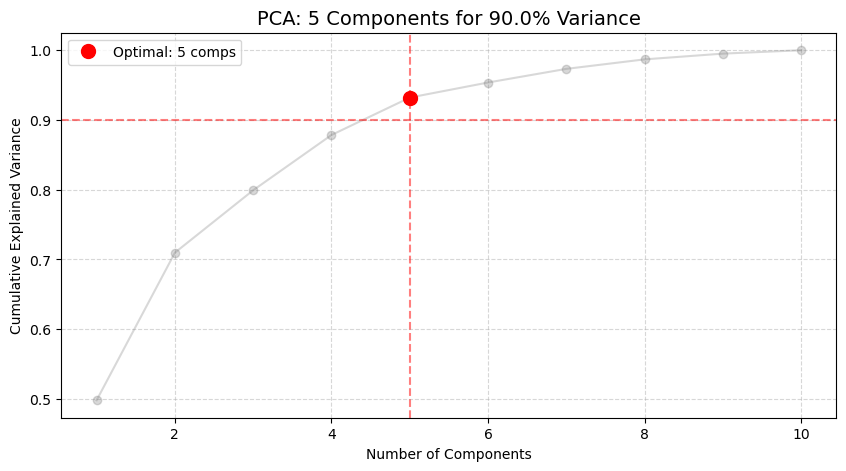

In [7]:
fifa_components = select_optimal_pca(df_fifa_num,0.9)

#### Thoughts
- For this dataset we see that we get 80% of the variance with 3 components, so for this particular dataset the data is well-preserved in lower dimensions

[0.33799453 0.17607443 0.10260513 0.09991293 0.09316691 0.09237333
 0.05521363 0.02978858 0.01205155 0.00081898]
[0.33799453 0.51406896 0.61667409 0.71658702 0.80975393 0.90212726
 0.95734089 0.98712947 0.99918102 1.        ]
✅ To capture 90.0% variance, you need 6 components.


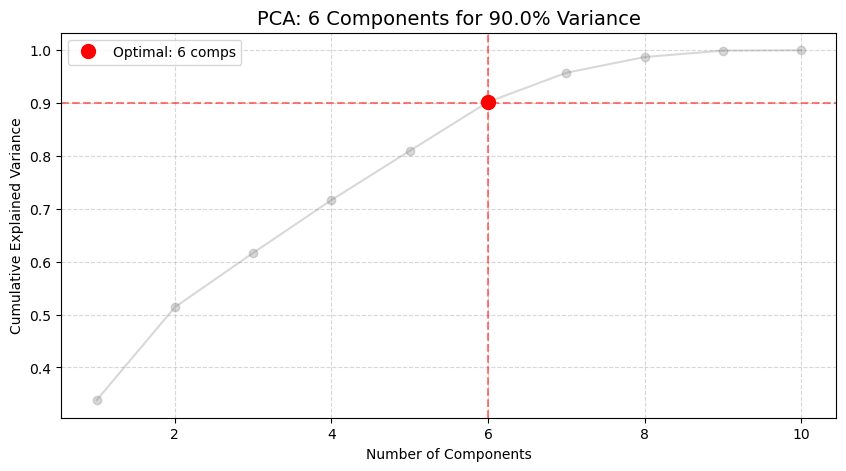

In [8]:
airlines_components = select_optimal_pca(df_air_num,0.9)

#### Thoughts
- For this dataset we see that we get 80% of the variance with 5 components.So for this dataset the data is not well-preserve in lower dimensions since we need more components to make up a certain variance percentage

### PCA Space representation

In [9]:
scaler = StandardScaler()
X_fifa= scaler.fit_transform(df_fifa_num)
X_air  = scaler.fit_transform(df_air_num)

In [19]:
def pca_projected_data(X, x_components=2):
    # it is considered that X is already scaled
    pca_final = PCA(n_components=x_components) # Or your optimal 'n'
    components = pca_final.fit_transform(X)
    return components,pca_final.components_


#### Fifa

In [20]:
fifa_pca, fifa_pca_components_= pca_projected_data(X_fifa,fifa_components)
print(fifa_pca.shape)
print(fifa_pca_components_.shape)

(18852, 5)
(5, 10)


In [61]:
loadings_fifa = pd.DataFrame(
    fifa_pca_components_.T,
    columns=["PC1","PC2","PC3","PC4","PC5"],
    index=df_fifa_num.columns
)

In [62]:
loadings_fifa

,PC1,PC2,PC3,PC4,PC5
Finishing,0.344703,-0.311950,0.239701,-0.202950,-0.100744
Short Passing,0.406795,0.088352,0.157004,0.185502,-0.154863
Standing Tackle,0.221201,0.562834,-0.186389,0.146416,0.060227
Sprint Speed,0.303068,-0.199692,-0.286122,-0.273696,0.737274
Strength,0.041131,0.377184,0.731230,-0.474544,0.212165
Dribbling,0.413966,-0.182601,0.037254,0.021462,0.038336
Crossing,0.401104,-0.046377,-0.091557,0.181849,0.131295
Interceptions,0.224338,0.562560,-0.127509,0.176002,0.057961
Vision,0.350845,-0.185817,0.294313,0.325458,-0.258111
GK Reflexes,-0.259913,-0.097257,0.392352,0.657596,0.533821


##### Analysis
- PC1 captures overall skill level across multiple abilities (technical, attacking, defensive, speed)
  - Short Passing (~0.40)
  - Finishing (~0.34)
  - Sprint Speed (~0.30)
  - Standing Tackle (~0.22)
- PC2 separates defensive/physical players from attacking player
  - High PC2 -> Defensive players: Physically strong and Tackling-focused
  - Low PC2 -> Attackers players: Fast attackers and Finishing-oriented players
- PC3 captures physical strength characteristics.
  - High PC3
    - Strong players
    - Likely center-backs or target forwards
  - Low PC3
    - Lighter, more agile players
- PC4 does not show any dominant feature
- PC5 clearly isolates speed as an independent dimension
  - High PC5:
    - Very fast players
    - Wingers / pace-based attackers
  - Low PC5:
    - Slower players

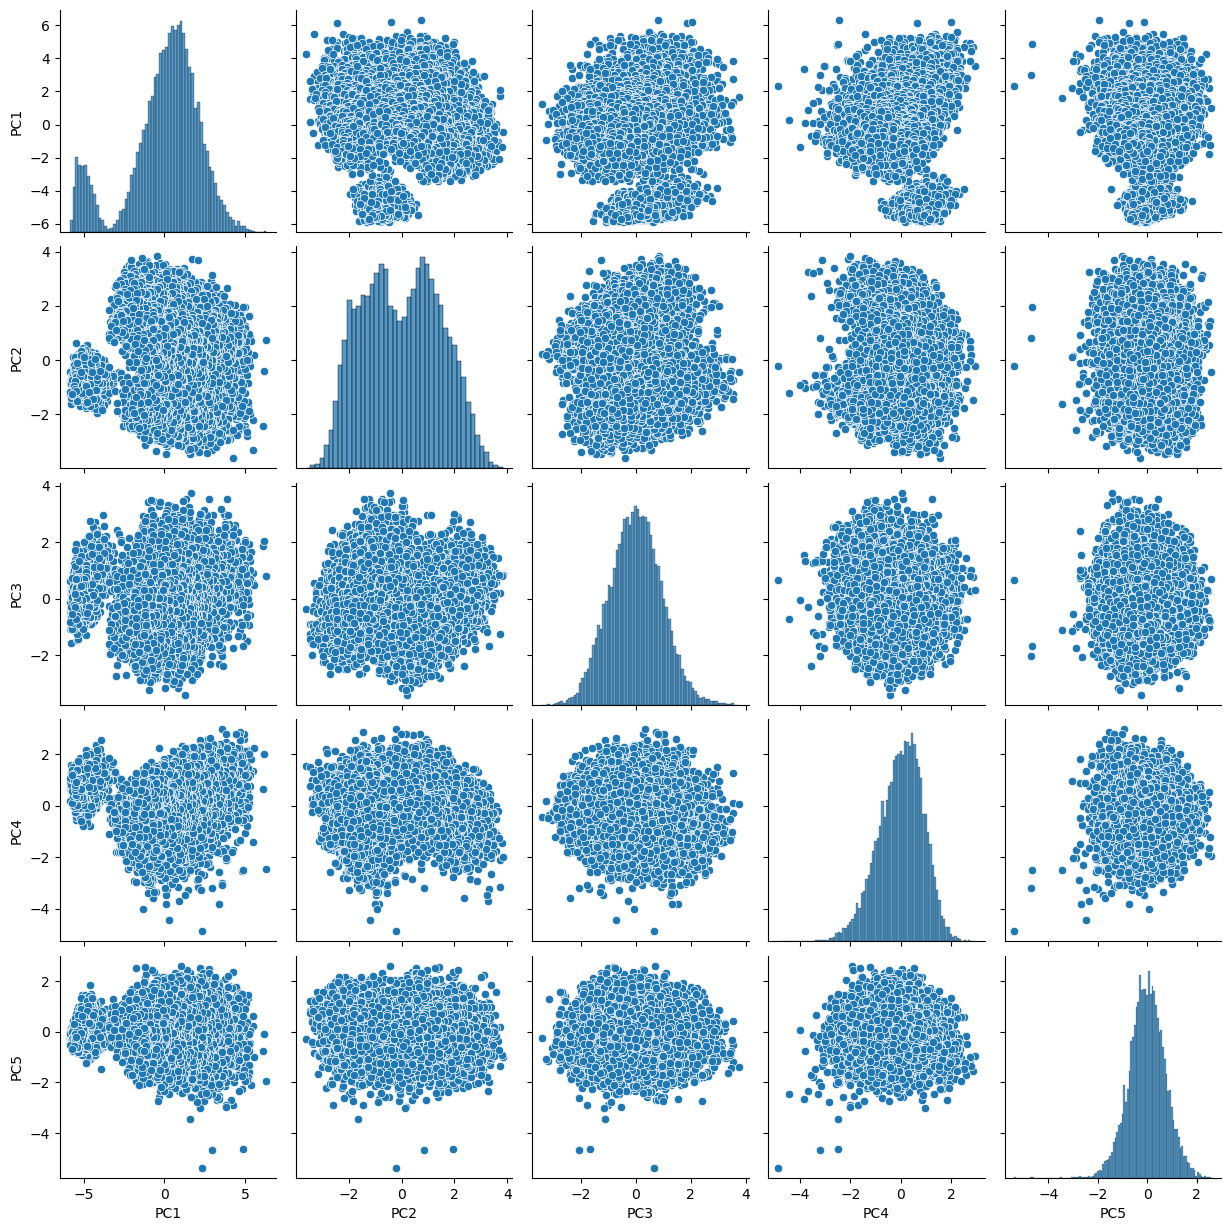

In [18]:
sns.pairplot(pd.DataFrame(fifa_pca, columns=["PC1","PC2","PC3","PC4","PC5"]))

##### Clustering

In [41]:
def kmeans_on_pca_plot(
    X_pca: np.ndarray,
    k_list=(2, 3, 4, 5, 6, 7, 8),
    random_state: int = 42,
    n_init="auto"
):

    X_pca = np.asarray(X_pca)
    if X_pca.ndim != 2:
        raise ValueError(f"X_pca must be 2D (n_samples, n_components). Got shape={X_pca.shape}")
    if len(k_list) == 0:
        raise ValueError("k_list cannot be empty.")
    if max(k_list) >= X_pca.shape[0]:
        raise ValueError("All k must be < n_samples for silhouette to work reliably.")

    ks = []
    silhouettes = []
    inertias = []
    models = []
    labels_list = []

    for k in k_list:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = model.fit_predict(X_pca)

        # silhouette requires at least 2 clusters in the result (usually true for k>=2)
        sil = silhouette_score(X_pca, labels) if len(np.unique(labels)) > 1 else np.nan

        ks.append(k)
        silhouettes.append(sil)
        inertias.append(model.inertia_)
        models.append(model)
        labels_list.append(labels)


    return ks, silhouettes, inertias,labels_list

In [ ]:
def plot_scores(ks,metric_values,metric_name):
        # ---- plot metric vs k ----
        plt.figure(figsize=(7, 4))
        plt.plot(ks, metric_values, marker="o")
        plt.xticks(ks)
        plt.xlabel("k (number of clusters)")
        plt.ylabel(metric_name)
        plt.title(f"KMeans model selection by {metric_name}")
        plt.show()

In [44]:
ks, silhouettes, inertias,labels_list =kmeans_on_pca_plot(fifa_pca)

In [55]:
np.unique(labels_list[2])

array([0, 1, 2, 3])

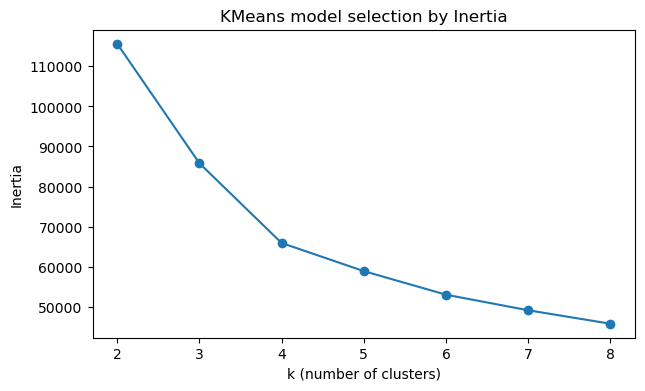

In [48]:
plot_scores(ks,inertias,"Inertia")

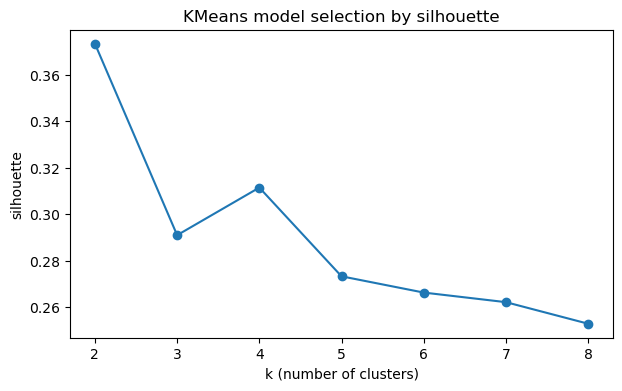

In [49]:
plot_scores(ks,silhouettes,"silhouette")

In [58]:
df_clustered = pd.DataFrame(fifa_pca, columns=["PC1","PC2","PC3","PC4","PC5"])
df_clustered['Cluster'] = labels_list[2].astype(str)


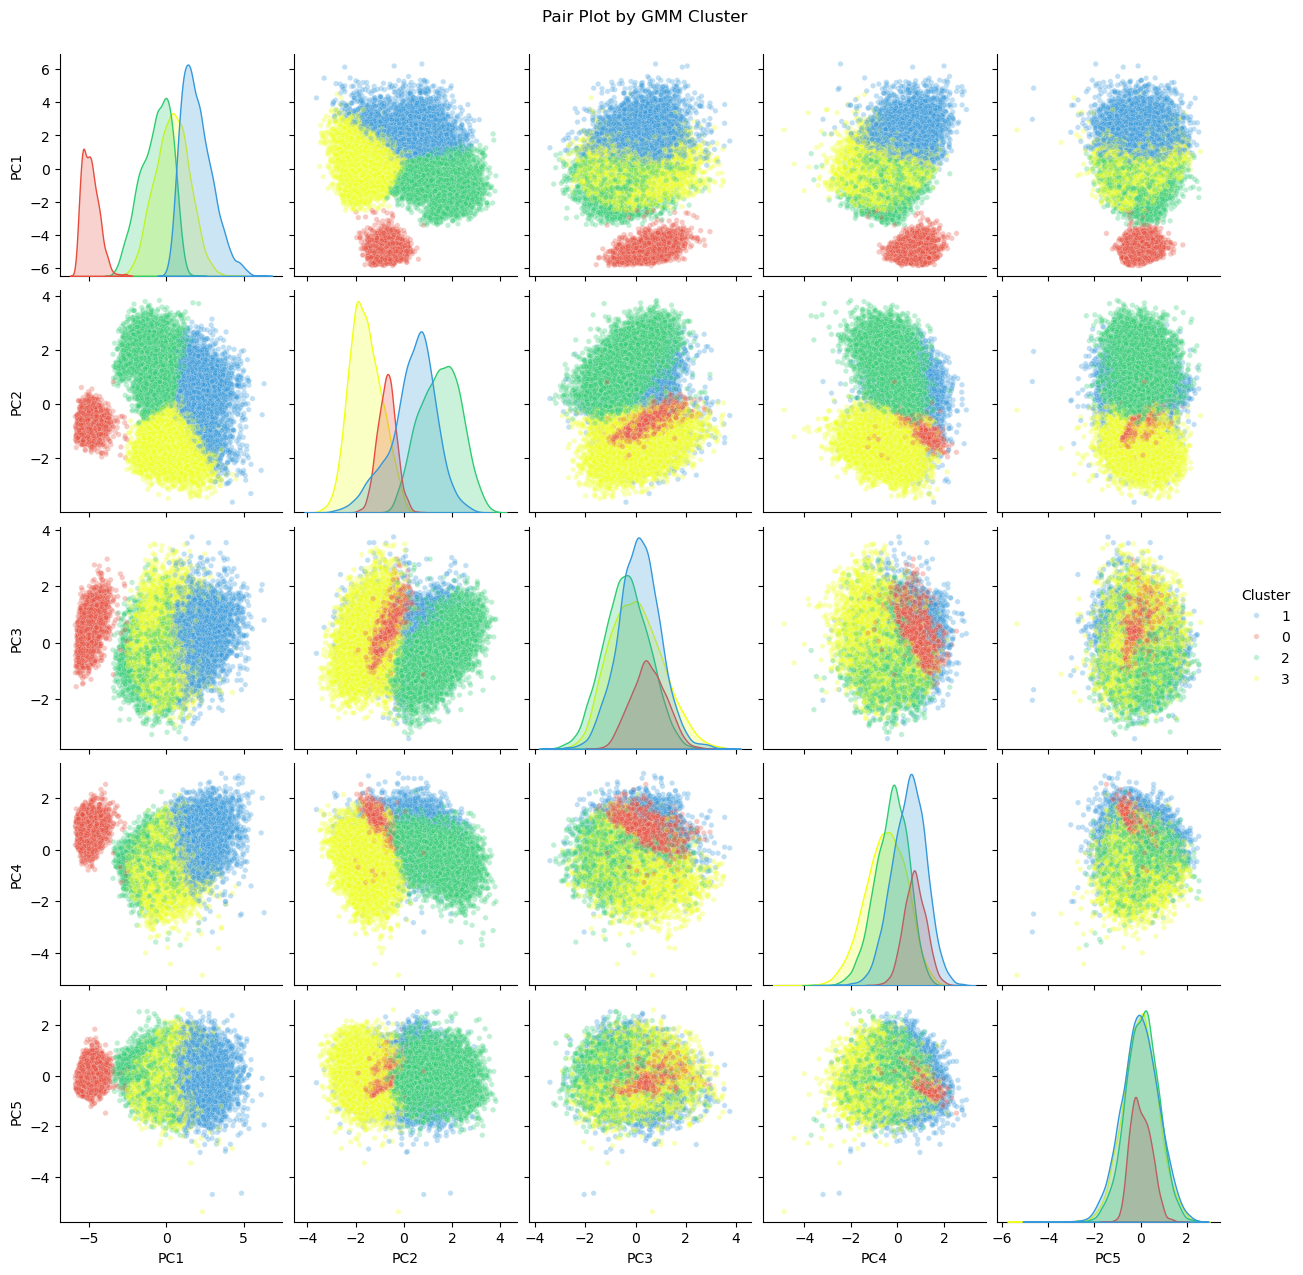

In [59]:
sns.pairplot(df_clustered, hue='Cluster', diag_kind='kde',
             palette={'0': '#e74c3c', '1': '#3498db', '2': '#2ecc71','3':"#efff15"},
             plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Pair Plot by GMM Cluster', y=1.02)
plt.show()

#### Airlines

In [60]:
X_pca_air, airline_pca_components_= pca_projected_data(X_air,airlines_components)
print(X_pca_air.shape)
print(airline_pca_components_.shape)

(3999, 6)
(6, 10)


In [63]:
loadings_airlines = pd.DataFrame(
    airline_pca_components_.T,
    columns=["PC1","PC2","PC3","PC4","PC5","PC6"],
    index=df_air_num.columns
)

In [64]:
loadings_airlines

,PC1,PC2,PC3,PC4,PC5,PC6
Balance,0.384773,-0.056142,-0.116299,-0.109249,0.201291,-0.052121
Qual_miles,0.112229,0.230437,-0.224631,0.012953,0.437586,0.823347
cc1_miles,0.396717,-0.377394,-0.061257,-0.000837,-0.180210,0.073418
cc2_miles,0.009856,0.025375,0.900979,-0.267069,0.296296,0.080478
cc3_miles,0.059134,-0.075103,0.155667,0.899772,0.362717,-0.152171
Bonus_miles,0.476758,-0.249674,0.085803,0.035885,-0.137316,0.093611
Bonus_trans,0.452323,-0.193212,0.147993,0.025264,-0.160446,0.117318
Flight_miles_12mo,0.321546,0.583725,0.028347,0.039195,-0.117158,-0.161410
Flight_trans_12,0.323279,0.585832,0.029153,0.037049,-0.108039,-0.149468
Days_since_enroll,0.196420,-0.106933,-0.255637,-0.319604,0.667961,-0.461995


## 1) Escalar (solo numéricas) y definir un helper para plots

In [11]:
scaler = StandardScaler()
X_fifa= scaler.fit_transform(df_fifa_num)
X_air  = scaler.fit_transform(df_air_num)

In [ ]:
def plot_embedding(Z, title):
    plt.figure(figsize=(7,5))
    plt.scatter(Z[:,0], Z[:,1], s=10)
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(alpha=0.2)
    plt.show()

## 2) PCA (2D) + varianza explicada

FIFA 25 Players | PCA(2D) explained variance = 0.710


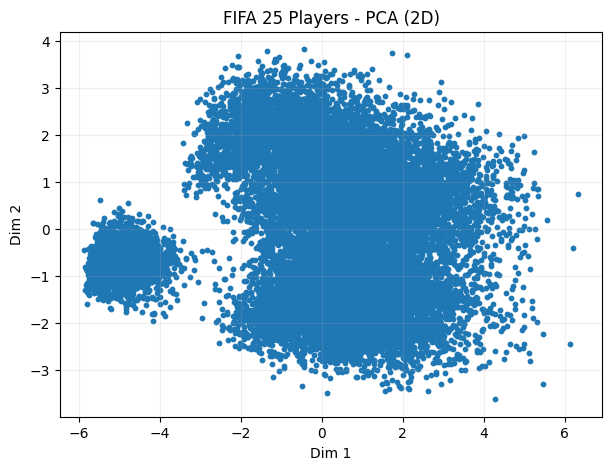

East West Airlines | PCA(2D) explained variance = 0.514


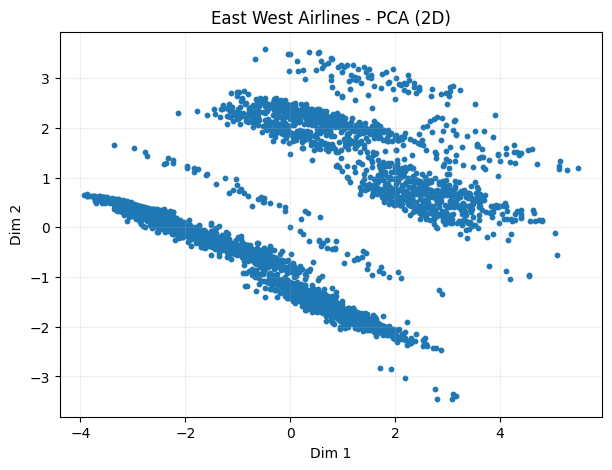

In [ ]:
def run_pca(X, dataset_name):
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X)
    evr = pca.explained_variance_ratio_.sum()
    print(f"{dataset_name} | PCA(2D) explained variance = {evr:.3f}")
    plot_embedding(Z, f"{dataset_name} - PCA (2D)")
    return Z, pca

Z_pca_fifa, pca_fifa = run_pca(X_fifa, "FIFA 25 Players")
Z_pca_air,  pca_air  = run_pca(X_air,  "East West Airlines")

## 3) Kernel PCA (2D)

Kernel PCA no tiene “explained variance” como PCA, así que lo evaluamos visualmente (y luego con DBSCAN en el Punto 2).

FIFA 25 Players | KernelPCA(2D) kernel=rbf, gamma=0.1000


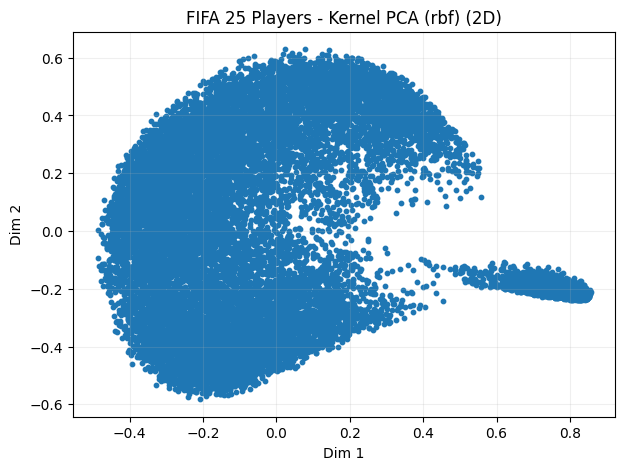

East West Airlines | KernelPCA(2D) kernel=rbf, gamma=0.1000


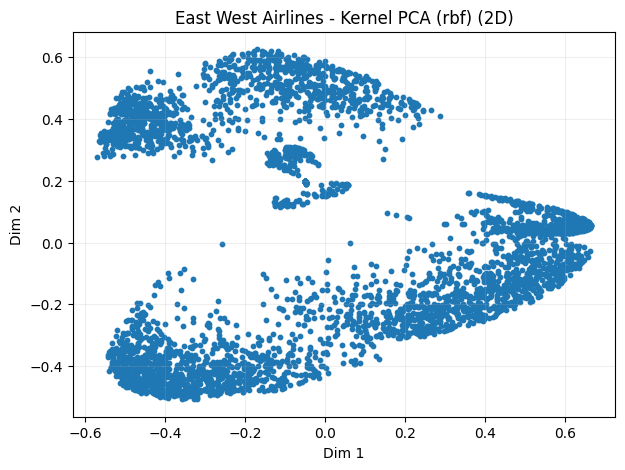

In [ ]:
def run_kpca(X, dataset_name, kernel="rbf"):
    # gamma base: 1 / num_features (buen punto de partida)
    gamma = 1 / X.shape[1]
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=gamma)
    Z = kpca.fit_transform(X)
    print(f"{dataset_name} | KernelPCA(2D) kernel={kernel}, gamma={gamma:.4f}")
    plot_embedding(Z, f"{dataset_name} - Kernel PCA ({kernel}) (2D)")
    return Z, kpca

Z_kpca_fifa, kpca_fifa = run_kpca(X_fifa, "FIFA 25 Players", kernel="rbf")
Z_kpca_air,  kpca_air  = run_kpca(X_air,  "East West Airlines", kernel="rbf")

## 4) t-SNE (2D)

FIFA 25 Players | t-SNE(2D) perplexity=30


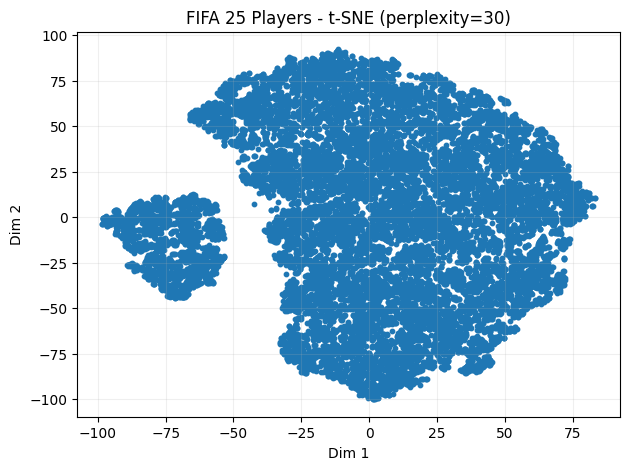

East West Airlines | t-SNE(2D) perplexity=30


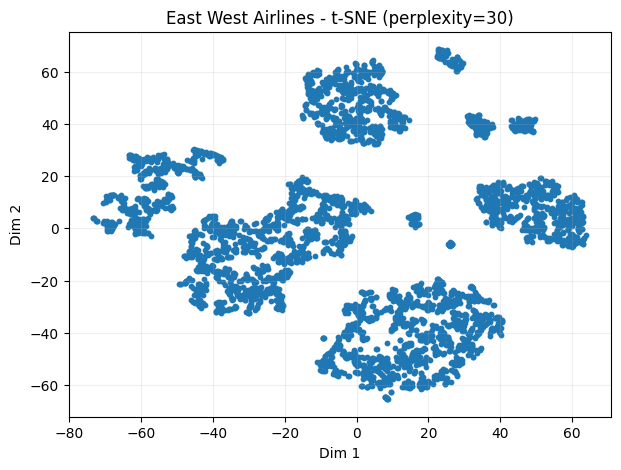

In [5]:
def run_tsne(X, dataset_name, perplexity=30):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    Z = tsne.fit_transform(X)
    print(f"{dataset_name} | t-SNE(2D) perplexity={perplexity}")
    plot_embedding(Z, f"{dataset_name} - t-SNE (perplexity={perplexity})")
    return Z, tsne

Z_tsne_fifa, tsne_fifa = run_tsne(X_fifa, "FIFA 25 Players", perplexity=30)
Z_tsne_air,  tsne_air  = run_tsne(X_air,  "East West Airlines", perplexity=30)

In [ ]:
um = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
Z_umap_fifa = um.fit_transform(X_fifa)
Z_umap_air  = um.fit_transform(X_air)

print(Z_umap_fifa.shape, Z_umap_air.shape)

c:\Users\isaac\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(18852, 2) (3999, 2)


## Interpretación de los embeddings (PCA, Kernel PCA, t-SNE y UMAP)

### Tamaño de los datos
- **FIFA 25 Players:** \(X\_\text{fifa}\) tiene forma **(18852, 10)** (18.852 jugadores, 10 variables numéricas).
- **East West Airlines:** \(X\_\text{air}\) tiene forma **(3999, 10)** (3.999 clientes, 10 variables numéricas).
- Todos los métodos redujeron a **2D**: **(18852, 2)** y **(3999, 2)**, respectivamente.

> Nota sobre UMAP: el *warning* indica que al fijar `random_state` se fuerza `n_jobs=1` para reproducibilidad (no paraleliza). No afecta la validez del embedding; solo el rendimiento.

---

### 1) PCA (2D)
- **FIFA (PCA):** se observa una **masa principal muy densa** y un **grupo claramente separado** hacia la izquierda. Esto sugiere que existe al menos un segmento distinto (posibles outliers/perfiles extremos), pero dentro del grupo principal hay **alto solapamiento**, por lo que la separabilidad no es totalmente clara en 2D.
- **Airlines (PCA):** se aprecian **estructuras más diferenciadas** (bandas/zonas separables) comparado con FIFA. Esto indica que una parte importante de la estructura puede capturarse incluso con una proyección lineal.

**Interpretación general:** PCA preserva estructura global basada en varianza; si los clusters no son lineales o se solapan en el espacio original, en 2D puede verse “mezclado”.

---

### 2) Kernel PCA (RBF, 2D)
- **FIFA (Kernel PCA):** el embedding toma forma de **una nube continua** con un “brazo/cola” hacia una región específica. Esto puede indicar una **estructura no lineal** y/o presencia de observaciones extremas; sin embargo, sigue predominando una **transición gradual** más que clusters compactos bien separados.
- **Airlines (Kernel PCA):** aparecen **regiones mejor separadas** (formas curvas/arcos), lo que sugiere que hay patrones no lineales en el comportamiento de clientes que Kernel PCA logra resaltar mejor que PCA.

**Interpretación general:** Kernel PCA puede “desenrollar” relaciones no lineales y mejorar separabilidad, especialmente cuando PCA no logra separar.

---

### 3) t-SNE (2D)
- **FIFA (t-SNE):** se mantiene un **grupo grande dominante** y se observa al menos un **“isla” separada**, además de subestructura interna. Esto sugiere que hay vecindades locales (microsegmentos) pero no necesariamente fronteras limpias entre grupos grandes.
- **Airlines (t-SNE):** se observan **múltiples islas claramente separadas**, lo que indica una separabilidad local muy marcada; esto suele ser favorable para algoritmos basados en densidad como DBSCAN.

**Interpretación general:** t-SNE está optimizado para preservar vecindades locales (visualización). Puede “exagerar” separaciones globales, por lo que es ideal para inspección visual y para probar DBSCAN, pero no debe interpretarse como distancias globales exactas.

---

### 4) UMAP (2D)
- Se generaron embeddings 2D exitosamente para ambos datasets (**(18852,2)** y **(3999,2)**).
- UMAP suele preservar estructura local y parte de la global, y frecuentemente produce espacios 2D muy adecuados para DBSCAN (zonas densas + separación natural).

**Interpretación general:** UMAP es un candidato fuerte para evaluar separabilidad con DBSCAN, especialmente si t-SNE mostró islas bien definidas.

---

## Conclusión del Punto 1 (Reducción de dimensionalidad)
- En **FIFA**, los métodos muestran una **estructura dominante** con posibles subgrupos y al menos un segmento separado, pero la separabilidad de múltiples clusters grandes no es totalmente evidente solo con el embedding (especialmente en PCA). Aquí es clave evaluar DBSCAN para ver si aparecen clusters robustos o si predomina una gran región con ruido.
- En **Airlines**, tanto PCA como (más claramente) Kernel PCA y t-SNE sugieren **mayor separabilidad**. Por lo tanto, se espera que DBSCAN detecte **más de un cluster** y que la representación reducida sea más útil para segmentación.

En el siguiente punto (DBSCAN), se evaluará formalmente esta separabilidad comparando para cada embedding: **número de clusters detectados**, **cantidad de ruido/outliers**, y (si aplica) métricas internas como Silhouette sobre puntos no-ruido.